In [28]:
import numpy as np
import pandas as pd
import seaborn as sns
import datetime as dt
import matplotlib.pyplot as plt
import statsmodels.api as sm
from imblearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import train_test_split, StratifiedKFold, StratifiedShuffleSplit, GridSearchCV, RepeatedStratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, balanced_accuracy_score, confusion_matrix, precision_recall_curve, roc_auc_score, make_scorer, accuracy_score, f1_score, r2_score, mean_absolute_error, mutual_info_score, roc_curve, zero_one_loss
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import LinearSVC, SVC
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.base import BaseEstimator, TransformerMixin, clone
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
from imblearn import pipeline as imbpipeline


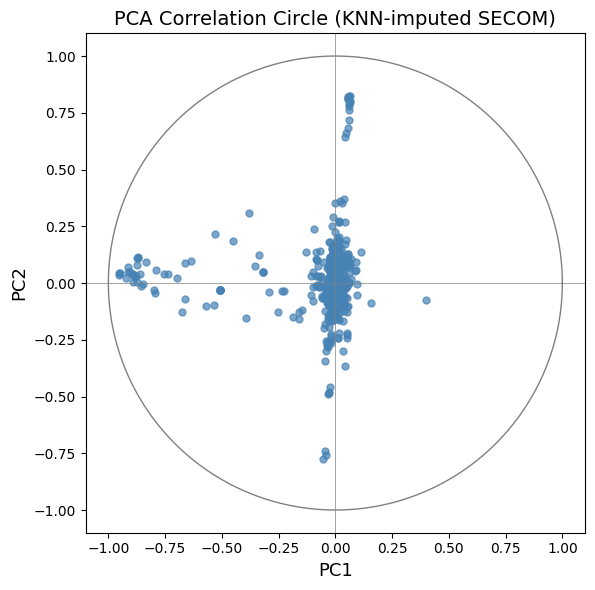

In [ ]:
secom = pd.read_csv(r'C:\Users\User\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
np.random.seed(42)
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = imputer.fit_transform(X)

# 3) 標準化
X_std = StandardScaler().fit_transform(X_imp)

# 4) PCA（手動協方差分解）
cov_mat = np.cov(X_std, rowvar=False)
eigen_val, eigen_vec = np.linalg.eigh(cov_mat)
idx_sorted = np.argsort(eigen_val)[::-1]
lamda_ = eigen_val[idx_sorted][:2]
vector_ = eigen_vec[:, idx_sorted][:, :2]

# 5) correlation circle
corr = vector_ * np.sqrt(lamda_)

theta = np.linspace(0, 2*np.pi, 361)
ucircle = np.c_[np.cos(theta), np.sin(theta)]

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(ucircle[:,0], ucircle[:,1], color='grey', lw=1)
ax.axhline(0, color='grey', lw=0.5)
ax.axvline(0, color='grey', lw=0.5)

# 只畫點，不加虛線和標籤
ax.scatter(corr[:,0], corr[:,1], color='steelblue', s=25, alpha=0.7)

ax.set_xlabel('PC1', fontsize=13)
ax.set_ylabel('PC2', fontsize=13)
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)

plt.tight_layout()
plt.show()  

### 所有機器學習模型10折的結果，不作特徵選擇，中位數補值
| 模型             | Mean Accuracy |    FAR | Sensitivity | Specificity |     GM |
| -------------- | ------------: | -----: | ----------: | ----------: | -----: |
| RandomForest   |        0.9138 | 0.0359 |      0.2069 |      0.9641 | 0.4123 |
| SVC            |        0.9282 | 0.0085 |      0.0375 |      0.9915 | 0.0854 |
| XGBoost        |        0.9274 | 0.0111 |      0.0583 |      0.9889 | 0.1502 |
| DecisionTree   |        0.8029 | 0.1581 |      0.2514 |      0.8419 | 0.4284 |
| LinearReg      |        0.8013 | 0.1667 |      0.3500 |      0.8333 | 0.5210 |
| Lasso-Logistic |        0.8452 | 0.1154 |      0.2903 |      0.8846 | 0.4417 |
---
### 所有機器學習模型的10折結果, 不作特徵選擇, KNN補值
| 模型             | Mean Accuracy |    FAR | Sensitivity | Specificity |     GM |
| -------------- | ------------: | -----: | ----------: | ----------: | -----: |
| RandomForest   |        0.9106 | 0.0385 |      0.1944 |      0.9615 | 0.3751 |
| SVC            |        0.9266 | 0.0094 |      0.0250 |      0.9906 | 0.0707 |
| XGBoost        |        0.9290 | 0.0085 |      0.0458 |      0.9915 | 0.1151 |
| DecisionTree   |        0.8189 | 0.1487 |      0.3611 |      0.8513 | 0.5149 |
| LinearReg      |        0.7925 | 0.1769 |      0.3597 |      0.8231 | 0.5263 |
| Lasso-Logistic |        0.8476 | 0.1154 |      0.3278 |      0.8846 | 0.4905 |
---
### 所有機器學習模型的10折結果, 作缺值, 相關性特徵選擇, KNN補值
| 模型             | Mean Accuracy |    FAR | Sensitivity | Specificity |     GM |
| -------------- | ------------: | -----: | ----------: | ----------: | -----: |
| RandomForest   |        0.9067 | 0.0436 |      0.2069 |      0.9564 | 0.3862 |
| SVC            |        0.9258 | 0.0111 |      0.0375 |      0.9889 | 0.0851 |
| XGBoost        |        0.9290 | 0.0103 |      0.0722 |      0.9897 | 0.1666 |
| DecisionTree   |        0.7662 | 0.2026 |      0.3250 |      0.7974 | 0.4985 |
| LinearReg      |        0.8077 | 0.1615 |      0.3736 |      0.8385 | 0.5170 |
| Lasso-Logistic |        0.8444 | 0.1179 |      0.3139 |      0.8821 | 0.4809 |
---
### 所有機器學習模型的10折結果, 不作缺值, 相關性特徵選擇, KNN補值, 隨機森林特徵選擇
| 模型             | Mean Accuracy |    FAR | Sensitivity | Specificity |     GM |
| -------------- | ------------: | -----: | ----------: | ----------: | -----: |
| RandomForest   |        0.8811 | 0.0761 |      0.2792 |      0.9239 | 0.4748 |
| SVC            |        0.9090 | 0.0385 |      0.1708 |      0.9615 | 0.3280 |
| XGBoost        |        0.9250 | 0.0179 |      0.1194 |      0.9821 | 0.2627 |
| DecisionTree   |        0.7949 | 0.1718 |      0.3292 |      0.8282 | 0.5024 |
| LinearReg      |        0.7638 | 0.2214 |      0.5583 |      0.7786 | 0.6449 |
| Lasso-Logistic |        0.7734 | 0.2068 |      0.4944 |      0.7932 | 0.6130 |
---
### 所有機器學習模型的10折結果, 作缺值, 相關性, KNN補值, 隨機森林特徵選擇
| 模型             | Mean Accuracy |    FAR | Sensitivity | Specificity |     GM |
| -------------- | ------------: | -----: | ----------: | ----------: | -----: |
| RandomForest   |        0.8843 | 0.0769 |      0.3403 |      0.9231 | 0.5452 |
| SVC            |        0.9099 | 0.0393 |      0.1944 |      0.9607 | 0.3758 |
| XGBoost        |        0.9322 | 0.0154 |      0.1931 |      0.9846 | 0.4061 |
| DecisionTree   |        0.7590 | 0.2145 |      0.3875 |      0.7855 | 0.5358 |
| LinearReg      |        0.7566 | 0.2291 |      0.5597 |      0.7709 | 0.6364 |
| Lasso-Logistic |        0.7702 | 0.2094 |      0.4861 |      0.7906 | 0.6034 |
---
### 所有機器學習模型的10折結果, KNN補值, 50次隨機森林投票特徵選取30個 (seed=42)
| 模型             | Mean Accuracy |    FAR | Sensitivity | Specificity |     GM |
| -------------- | ------------: | -----: | ----------: | ----------: | -----: |
| RandomForest   |        0.8372 | 0.1410 |      0.5319 |      0.8590 | 0.6660 |
| SVC            |        0.8468 | 0.1128 |      0.2778 |      0.8872 | 0.4578 |
| XGBoost        |        0.9058 | 0.0496 |      0.2792 |      0.9504 | 0.4667 |
| DecisionTree   |        0.7071 | 0.2795 |      0.5181 |      0.7205 | 0.6000 |
| Lasso-Logistic |        0.7375 | 0.2513 |      0.5833 |      0.7487 | 0.6561 |
---
### 所有機器學習模型的10折結果, KNN補值, 50次隨機森林投票特徵選取50個 (seed=611211106)
| 模型             | Mean Accuracy |    FAR | Sensitivity | Specificity |     GM |
| -------------- | ------------: | -----: | ----------: | ----------: | -----: |
| RandomForest   |        0.8292 | 0.1453 |      0.4653 |      0.8547 | 0.6245 |
| SVC            |        0.8405 | 0.1197 |      0.2736 |      0.8803 | 0.4749 |
| XGBoost        |        0.9090 | 0.0462 |      0.2750 |      0.9538 | 0.5022 |
| DecisionTree   |        0.7158 | 0.2701 |      0.5111 |      0.7299 | 0.5942 |
| Lasso-Logistic |        0.7398 | 0.2496 |      0.5833 |      0.7504 | 0.6488 |



---


### 多元迴歸係數排序特徵, 迭代k找最佳test_acc取前k=21的features
| 模型             | Accuracy |    FAR | Sensitivity | Specificity |     GM |
| -------------- | ------------: | -----: | ----------: | ----------: | -----: |
| DecisionTree   |        0.8312 | 0.1297 |      0.2857 |      0.8703 | 0.4987 |


In [ ]:
secom = pd.read_csv(r'C:\Users\User\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
np.random.seed(42)
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=550].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=50].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_tr_imp = imputer.fit_transform(X_train)
X_te_imp = imputer.transform(X_test)

feature_names = X_train.columns.to_list()
p = X_tr_imp.shape[1]

t_vals = []
for j in range(p):
    Xi = sm.add_constant(X_tr_imp[:, j])         # y ~ 1 + x_j
    try:
        fit = sm.OLS(y_train.values, Xi).fit()
        t_vals.append(fit.tvalues[1])            # slope 的 t 值
    except Exception:
        t_vals.append(0.0)                       # 退避：發生數值問題時設 0

abs_t = np.abs(np.array(t_vals))
rank_idx = np.argsort(-abs_t)                    # 由大到小
ranked_features = [feature_names[i] for i in rank_idx]

smote = SMOTE(sampling_strategy=1.0, k_neighbors=5, random_state=42)

best = {"k": None, "train_acc": -1, "test_acc": -1}
records = []

for k in range(1, p+1):
    sel = rank_idx[:k]
    Xtr_k, Xte_k = X_tr_imp[:, sel], X_te_imp[:, sel]

    Xtr_bal, ytr_bal = smote.fit_resample(Xtr_k, y_train)

    clf = DecisionTreeClassifier(criterion='gini', max_depth=6, random_state=42)
    clf.fit(Xtr_bal, ytr_bal)

    y_tr_hat = clf.predict(Xtr_k)
    y_te_hat = clf.predict(Xte_k)

    tr_acc = accuracy_score(y_train, y_tr_hat)
    te_acc = accuracy_score(y_test,  y_te_hat)
    records.append((k, tr_acc, te_acc))

    if (te_acc > best["test_acc"]) or \
       (np.isclose(te_acc, best["test_acc"]) and tr_acc > best["train_acc"]) or \
       (np.isclose(te_acc, best["test_acc"]) and np.isclose(tr_acc, best["train_acc"]) and (best["k"] is None or k < best["k"])):
        best.update({"k": k, "train_acc": tr_acc, "test_acc": te_acc})

print(f"Best k = {best['k']} | train_acc = {best['train_acc']:.4f}, test_acc = {best['test_acc']:.4f}")
best_features = [feature_names[i] for i in rank_idx[:best["k"]]]

sel = rank_idx[:best["k"]]
Xtr_k, Xte_k = X_tr_imp[:, sel], X_te_imp[:, sel]
Xtr_bal, ytr_bal = smote.fit_resample(Xtr_k, y_train)

final_clf = DecisionTreeClassifier(criterion='gini', max_depth=6, random_state=42)
final_clf.fit(Xtr_bal, ytr_bal)
y_te_hat = final_clf.predict(Xte_k)

res = compute_metrics(y_test.values, y_te_hat)
print(f"ACC={res['acc']:.4f} | FAR={res['FAR']:.4f} | sens={res['sensitivity']:.4f} | spec={res['specificity']:.4f} | GM={res['GM']:.4f}")
print(res['cm'])

Best k = 21 | train_acc = 0.9010, test_acc = 0.8312
Selected features (top-k): ['x104', 'x511', 'x60', 'x349', 'x130', 'x432', 'x65', 'x22', 'x126', 'x431', 'x435', 'x317', 'x436', 'x437', 'x29', 'x123', 'x352', 'x125', 'x214', 'x181'] ...
ACC=0.8312 | FAR=0.1297 | sens=0.2857 | spec=0.8703 | GM=0.4987
[[255  38]
 [ 15   6]]


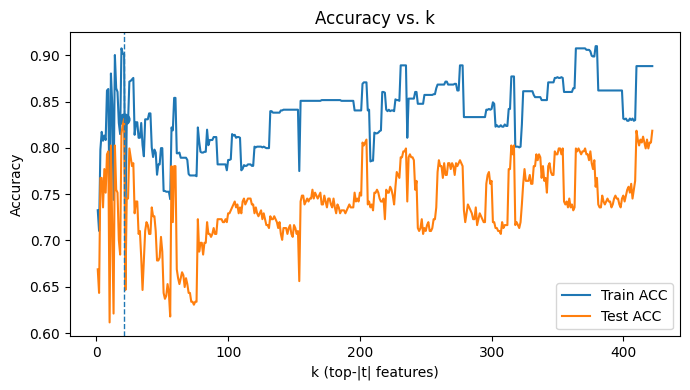

In [26]:
# 將每次 k 的結果轉成表格
rec_df = pd.DataFrame(records, columns=["k", "train_acc", "test_acc"])

# 取得最佳 k 的 test_acc 供標註
best_k = best["k"]
best_test = rec_df.loc[rec_df["k"] == best_k, "test_acc"].values[0]

plt.figure(figsize=(7,4))
plt.plot(rec_df["k"], rec_df["train_acc"], label="Train ACC")
plt.plot(rec_df["k"], rec_df["test_acc"], label="Test ACC")
plt.axvline(best_k, linestyle="--", linewidth=1)
plt.scatter([best_k], [best_test], s=60)

plt.xlabel("k (top-|t| features)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs. k")
plt.legend()
plt.tight_layout()
plt.show()

---
---

### 隨機森林特徵排序, 迭代k找最佳test_acc取前k=105的features
| 模型             | Accuracy |    FAR | Sensitivity | Specificity |     GM |
| -------------- | ------------: | -----: | ----------: | ----------: | -----: |
| DecisionTree   |        0.8248 | 0.1433 |      0.3810 |      0.8567 | 0.5713 |


[DT] Best k by TEST ACC = 105
[DT] Train ACC = 0.8667, Test ACC = 0.8248


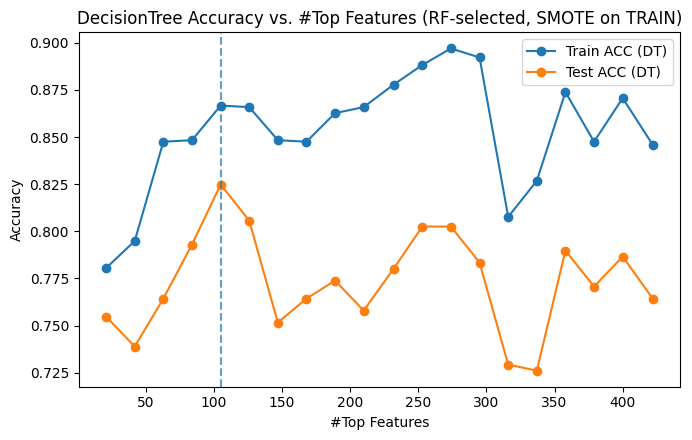

[DT-TEST @ k=105] acc=0.8248 FAR=0.1433 sens=0.3810 spec=0.8567 GM=0.5713


In [30]:
secom = pd.read_csv(r'C:\Users\User\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
np.random.seed(42)
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=550].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=50].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

imp = SimpleImputer(strategy='median')
smote_base = SMOTE(sampling_strategy=1.0, k_neighbors=5, random_state=42)  # 迴圈內會被覆蓋
dt_pipe_tpl = imbpipeline.Pipeline(steps=[
    ('impute', imp),
    ('smote', smote_base),
    ('clf', DecisionTreeClassifier(max_depth=6, min_samples_leaf=15,
                                   min_samples_split=20, random_state=42))
])

# ── 2) KNN補值：只在訓練集 fit，避免洩漏 ──
knn = KNNImputer(n_neighbors=10, weights='distance')
X_train_imp = pd.DataFrame(knn.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_imp  = pd.DataFrame(knn.transform(X_test), columns=X_test.columns, index=X_test.index)

# ── 先在「訓練集」做一次 SMOTE，用於計算特徵重要度的排序 ──
minority_n = int((y_train == 1).sum())
k_smote = max(1, min(5, minority_n - 1))  # 動態 k
smote = SMOTE(sampling_strategy=1.0, k_neighbors=k_smote, random_state=42)
Xb_imp, yb = smote.fit_resample(X_train_imp, y_train)

# ── 3) 先用全特徵的 RF 在「訓練集」上估重要度並排序 ──
rf_base = RandomForestClassifier(n_estimators=1000, min_samples_leaf=15, max_depth=6, min_samples_split=20, random_state=42, n_jobs=-1)
rf_base.fit(Xb_imp, yb)
importances = rf_base.feature_importances_
feat_order = np.argsort(importances)[::-1]  # 重要度由大到小

# 產生 k 值序列
p = X_train_imp.shape[1]
ks = sorted(set([max(5, int(p*ratio)) for ratio in np.linspace(0.05, 1.0, 20)]))
ks = [k for k in ks if k <= p]

train_accs_dt, test_accs_dt = [], []

for k in ks:  # ks、feat_order 來自你上段程式
    cols_k = X_train.columns[feat_order[:k]]
    # 動態設定當前訓練集的 SMOTE k
    minority_n = int((y_train == 1).sum())
    k_sm = max(1, min(5, minority_n - 1))

    pipe_k = clone(dt_pipe_tpl)
    pipe_k.set_params(smote=SMOTE(sampling_strategy=1.0, k_neighbors=k_sm, random_state=42))

    # 注意：把「原始帶NA的資料」丟進去，讓 pipeline 內做補值與SMOTE（只在train作用）
    pipe_k.fit(X_train[cols_k], y_train)

    y_tr_hat = pipe_k.predict(X_train[cols_k])
    y_te_hat = pipe_k.predict(X_test[cols_k])

    train_accs_dt.append(accuracy_score(y_train, y_tr_hat))
    test_accs_dt.append(accuracy_score(y_test, y_te_hat))

# 找最佳 k（以 Test ACC）
best_idx = int(np.argmax(test_accs_dt))
best_k_dt = ks[best_idx]
print(f"[DT] Best k by TEST ACC = {best_k_dt}")
print(f"[DT] Train ACC = {train_accs_dt[best_idx]:.4f}, Test ACC = {test_accs_dt[best_idx]:.4f}")

# 視覺化
plt.figure(figsize=(7,4.5))
plt.plot(ks, train_accs_dt, marker='o', label='Train ACC (DT)')
plt.plot(ks, test_accs_dt, marker='o', label='Test ACC (DT)')
plt.axvline(best_k_dt, linestyle='--', alpha=0.7)
plt.title('DecisionTree Accuracy vs. #Top Features (RF-selected, SMOTE on TRAIN)')
plt.xlabel('#Top Features')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

# 用最佳 k 重訓並回報完整指標（若你已定義 compute_metrics 就用它）
cols_best = X_train.columns[feat_order[:best_k_dt]]
best_pipe_dt = clone(dt_pipe_tpl)
best_pipe_dt.set_params(smote=SMOTE(sampling_strategy=1.0, k_neighbors=k_sm, random_state=42))
best_pipe_dt.fit(X_train[cols_best], y_train)
y_te_hat_best = best_pipe_dt.predict(X_test[cols_best])

try:
    m = compute_metrics(y_test.values, y_te_hat_best)
    print(f"[DT-TEST @ k={best_k_dt}] acc={m['acc']:.4f} FAR={m['FAR']:.4f} "
          f"sens={m['sensitivity']:.4f} spec={m['specificity']:.4f} GM={m['GM']:.4f}")
except NameError:
    print(f"[DT-TEST @ k={best_k_dt}] ACC={accuracy_score(y_test, y_te_hat_best):.4f}")